# **Directed percolation in Rust-Python**

First stab at implementing DP in Rust with a Python convenience wrapper.

<hr>

## Preliminaries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from typing import Any, Callable
from numpy.typing import NDArray
from dprs import sim
from dprs.viz import Viz
from dprs.file import create_dir, create_directories, export_plots, export_plot

<hr>

## Simulation

In [2]:
class Parameters:
    dim = sim.Dimension.D2
    processing = sim.Processing.Parallel
    n_x: int = 101 #10_000
    n_y: int = 61 #10_000
    n_z: int = 1
    edge_topology_x = sim.Topology.Periodic
    edge_topology_y = sim.Topology.Periodic
    edge_topology_z = sim.Topology.Unspecified
    edge_bc_x = (sim.BoundaryCondition.Floating, sim.BoundaryCondition.Floating)
    edge_bc_y = (sim.BoundaryCondition.Floating, sim.BoundaryCondition.Floating)
    edge_bc_z = (sim.BoundaryCondition.Unspecified, sim.BoundaryCondition.Unspecified)
    edge_values_x = (True, True)
    edge_values_y = (True, True)
    edge_values_z = (False, False)
    p: float = 0.1
    seed: int = 1
    n_iterations: int = 5
    sample_rate: int = 1
    n_threads: int = 8
    serial_skip: int = 1
    do_buffering: bool = False
parameters = Parameters()

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [3]:
n_lattices: int
raw_lattices: list[list[bool]] 
(n_lattices, raw_lattices,)= sim.dp(parameters)
n_lattices

6


Dimension:   D2
Grid shape:  (101, 61, 1)
Topology x:  Periodic
Topology y:  Periodic
Topology z:  Unspecified
Edge x b.c.: (Floating, Floating)
Edge y b.c.: (Floating, Floating)
Edge z b.c.: (Unspecified, Unspecified)
Edge x vals: (true, true)
Edge y vals: (true, true)
Edge z vals: (false, false)
Probability: 0.1
Random seed: 1
Iterations:  5
Sample rate: 1
Threads:     8
Serial skip: 1
Buffering:   false

Serial:   0.000s
Parallel: 0.000s
Parallel speedup => 1.33x



The function `sim.dp` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all them concatenated into one long 1d list.

In [4]:
raw_lattices: NDArray = np.array(raw_lattices, dtype=np.bool,) 
raw_lattices.shape

(6, 6161)

Next, we convert this long list into a 2+1d numpy array, with the last index being the lattice slice number. Care must be taken to reshape by the grid dimensions in the correct order: the fastest index in the list is the x coordinate, etc., so the reshaping parameters need to be given in reverse order `(n_lattices, y, x)`.

In [5]:
lattices: NDArray = raw_lattices.reshape(
    n_lattices, 
    parameters.n_y, parameters.n_x,
    ).T
lattices.shape

(101, 61, 6)

<hr>

## Visualization

In [ ]:
viz = Viz(dpi=250)
sim_root_name: str = "dp"
n: int
name: str
title: str

Visualize the initial lattice:

In [7]:
make_title: Callable \
    = lambda n: rf"$p={parameters.p}$    $s={parameters.seed}$    $n={n}$"

In [8]:
make_name: Callable \
    = lambda n: (
        f"{sim_root_name}_lattice"
        + f"_p{parameters.p}".replace(".", "p")
        + f"_s{parameters.seed}"
        + f"_n{n}"
    )

dp_lattice_p0p1_s1_n0


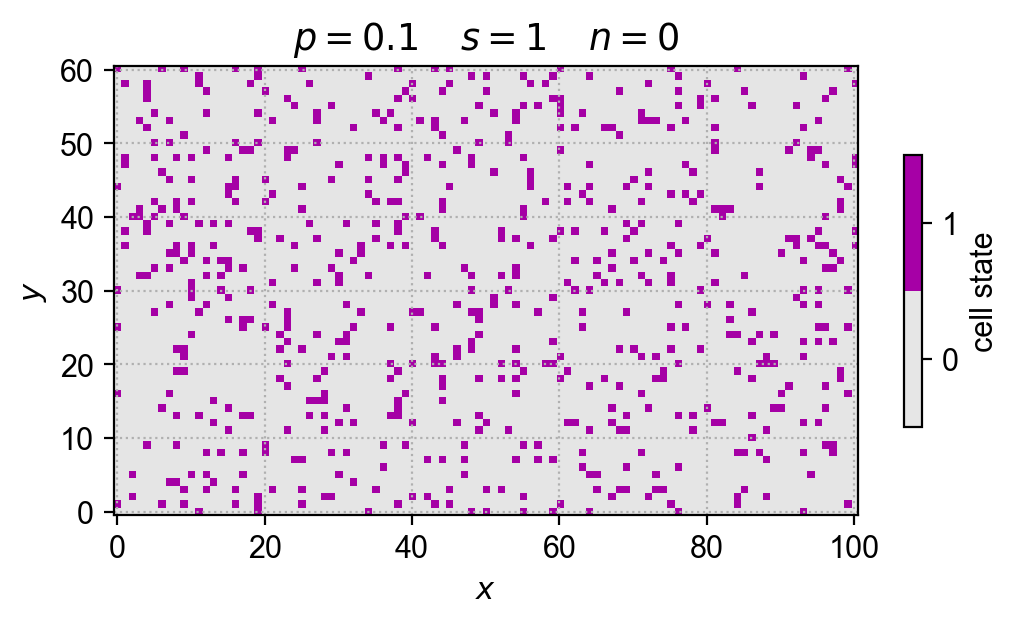

In [9]:
n = 0
name = make_name(n)
viz.image_lattice(name, make_title(n), lattices, parameters, i_lattice=n,)
print(name)
plt.show()

Visualize the final lattice:

dp_lattice_p0p1_s1_n5


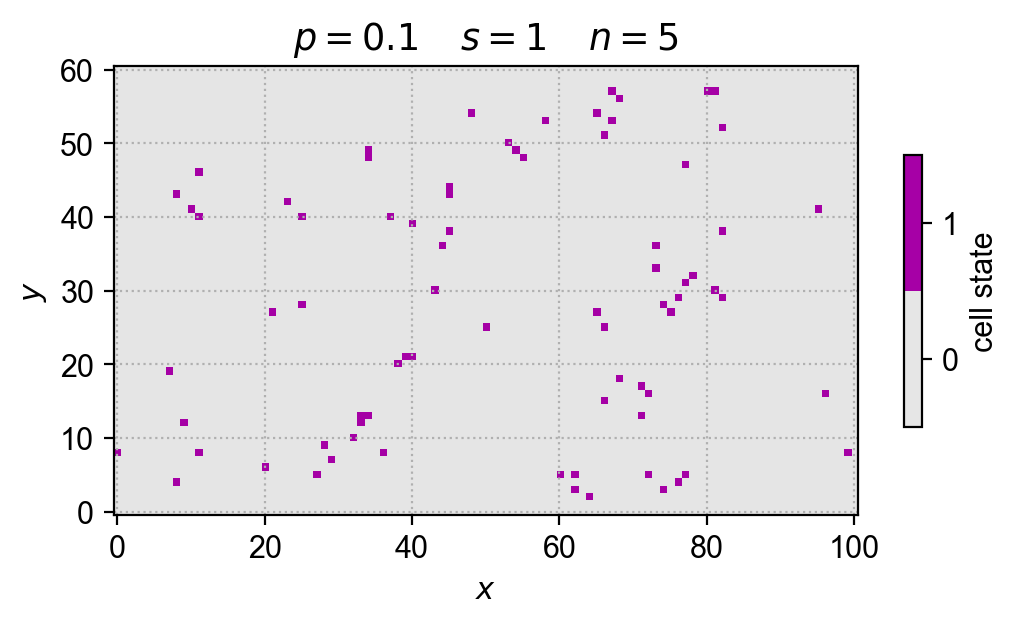

In [10]:
n = n_lattices-1
name = make_name(n)
viz.image_lattice(name, make_title(n), lattices, parameters, i_lattice=n,)
print(name)
plt.show()

<hr>

## Export

In [11]:
plots_dir: str = create_directories((os.path.curdir,"",), "plots",)
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots'